In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df_soil = pd.read_csv('texas.csv')
df_weather = pd.read_csv('texas_weather_2024.csv')

In [31]:
df_soil.head()

,areasymbol,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,hzdept_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r
0,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0
1,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0
2,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0
3,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN
4,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN


In [54]:
print(df_soil.shape)
print(df_soil.info())
print(df_soil.describe())

(49146, 20)
<class 'pandas.DataFrame'>
RangeIndex: 49146 entries, 0 to 49145
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   areasymbol     49146 non-null  str    
 1   musym          49146 non-null  str    
 2   muname         49146 non-null  str    
 3   compname       49146 non-null  str    
 4   saverest       49146 non-null  str    
 5   taxorder       48222 non-null  str    
 6   drainagecl     48499 non-null  str    
 7   elev_r         49112 non-null  float64
 8   slope_r        49146 non-null  float64
 9   hzdept_r       49146 non-null  int64  
 10  hzdepb_r       49146 non-null  int64  
 11  ph1to1h2o_r    48413 non-null  float64
 12  om_r           48349 non-null  float64
 13  ec_r           48415 non-null  float64
 14  cec7_r         44311 non-null  float64
 15  awc_r          48412 non-null  float64
 16  cropname       45004 non-null  str    
 17  yldunits       44999 non-null  str    
 18  nonir

In [53]:
# Missing values
print(df_soil.isnull().sum())

# 1. Calculate as numbers first
missing_pct = (df_soil.isnull().sum() / len(df_soil) * 100).round(2)
# 2. Use to_string() to force display of all rows
print("\n--- Full Missing Percentage List ---")
print(missing_pct.map(lambda x: f"{x:>6.2f} %").to_string())

areasymbol           0
musym                0
muname               0
compname             0
saverest             0
taxorder           924
drainagecl         647
elev_r              34
slope_r              0
hzdept_r             0
hzdepb_r             0
ph1to1h2o_r        733
om_r               797
ec_r               731
cec7_r            4835
awc_r              734
cropname          4142
yldunits          4147
nonirryield_r     8543
irryield_r       36347
dtype: int64

--- Full Missing Percentage List ---
areasymbol         0.00 %
musym              0.00 %
muname             0.00 %
compname           0.00 %
saverest           0.00 %
taxorder           1.88 %
drainagecl         1.32 %
elev_r             0.07 %
slope_r            0.00 %
hzdept_r           0.00 %
hzdepb_r           0.00 %
ph1to1h2o_r        1.49 %
om_r               1.62 %
ec_r               1.49 %
cec7_r             9.84 %
awc_r              1.49 %
cropname           8.43 %
yldunits           8.44 %
nonirryield_r     17.

In [ ]:
# Number of unique values
df_soil.nunique()

areasymbol        232
musym            3273
muname           6204
compname         1565
saverest           53
taxorder            9
drainagecl          8
elev_r            917
slope_r            82
hzdept_r            1
hzdepb_r          117
ph1to1h2o_r        54
om_r              162
ec_r               70
cec7_r            409
awc_r              34
cropname           49
yldunits            7
nonirryield_r     229
irryield_r        187
dtype: int64

Features:
* Use for both:
    * pH: ph1to1h20_r
    * Nutrient: om_r
    * EC (Electrical Conductivity): ec_r
    * CEC (Cation Exchange Capacity): cec7_r
    * Soil type: taxorder
    * Available Water Capacity: awc_r
    * Drainage class: dracinagecl
    * Depth to restrictive layer/horizon bottom: hzdepb_r
    * Altitude or elevation: elev_r
    * Slope: slope_r
* Use for crop recommendation (required to stanradrize units using yilunits)
    * nonirryield_r
    * irryield_r


Target variable:
* cropname (for crop recommendation)
* for crop yield prediction
    * nonirryield_r 
    * irryield_r 

https://docs.google.com/document/d/1hZgvWIYF03py2quTsW1hpOCYE-pO2eVkZ7HLiCrpQ7E/edit?tab=t.0

### Crop recommendation

In [55]:
# Count of each class
print("Class counts:")
print(df_soil['cropname'].value_counts())

# Convert to the percentage
print()
print("Class percentages:")
print(df_soil['cropname'].value_counts(normalize=True).mul(100).round(2))

Class counts:
cropname
Improved bermudagrass    7684
Grain sorghum            7427
Cotton lint              5745
Wheat                    5083
Corn                     3704
Common bermudagrass      2386
Oats                     1997
Bahiagrass               1860
Alfalfa hay              1193
Peanuts                  1150
Soybeans                  968
Small grains grazeout     920
Weeping lovegrass         643
Introduced bluestem       476
Rice                      412
Kleingrass                395
Watermelons               381
Tall fescue               298
Corn silage               275
Onions                    271
Peaches                   189
Green peas                167
Sorghum grazed            165
Winter wheat              154
Barley                    151
Carrots                   101
Sorghum silage             99
Sorghum hay                91
Grapefruit                 79
Oranges                    79
Buffel grass               78
Caucasian bluestem         75
Sugarcane        

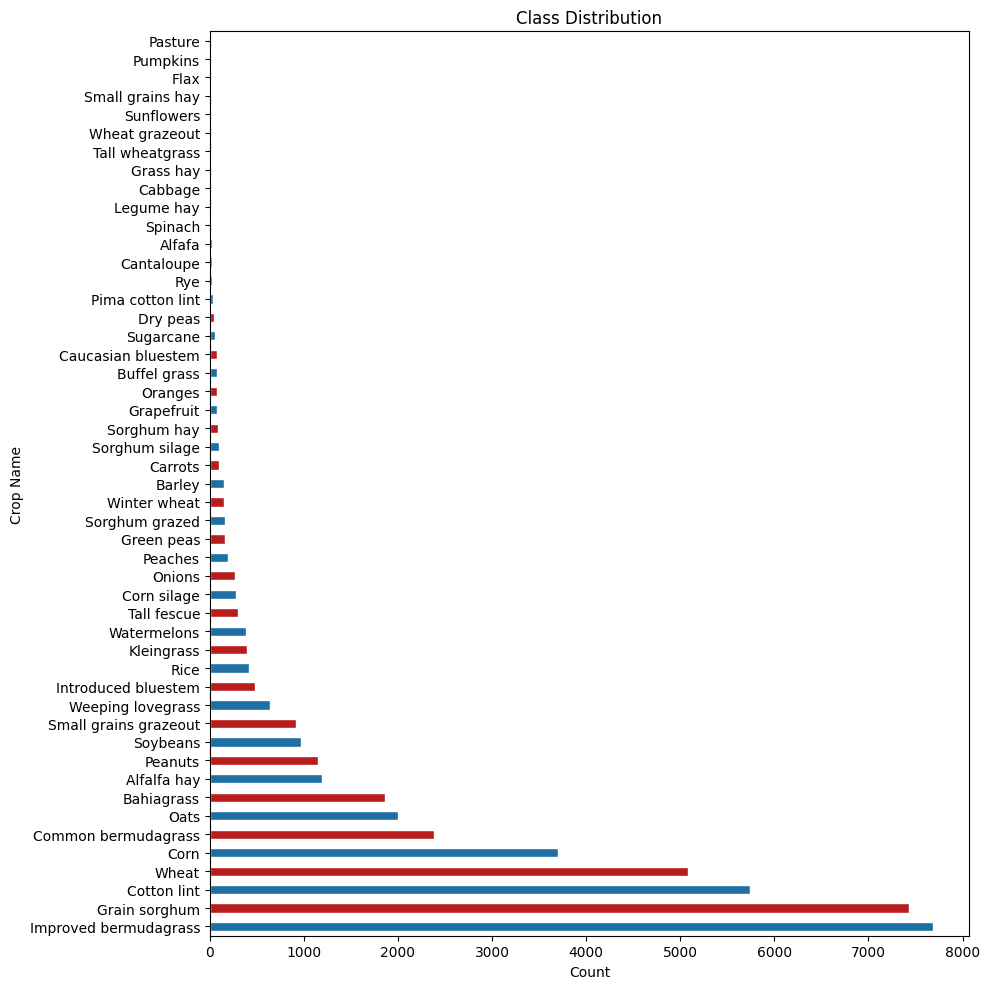

In [59]:
fig, ax = plt.subplots(figsize=(10, 10))

# Change 'kind' to 'barh' for horizontal bars
df_soil['cropname'].value_counts().plot(
    kind='barh',
    ax=ax,
    color=['#1d6fa4', '#b91c1c'],
    edgecolor='white', 
    width=0.5
)

# Swap labels to match the new orientation
ax.set_title('Class Distribution', fontsize=12)
ax.set_xlabel('Count')       # Now the x-axis shows the count
ax.set_ylabel('Crop Name')   # Now the y-axis shows the crop names

plt.tight_layout()
plt.show()

In [60]:
# Select numeric colmns
num_cols = df_soil.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", num_cols.tolist())

# Select categorical columns
cat_cols = df_soil.select_dtypes(include=['str', 'object']).columns
print("Categorical features:", cat_cols.tolist())

Numeric features: ['elev_r', 'slope_r', 'hzdept_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'nonirryield_r', 'irryield_r']
Categorical features: ['areasymbol', 'musym', 'muname', 'compname', 'saverest', 'taxorder', 'drainagecl', 'cropname', 'yldunits']


In [61]:
# Make a correlation matrix
cm = df_soil[num_cols].corr()
print(cm)

                 elev_r   slope_r  hzdept_r  hzdepb_r  ph1to1h2o_r      om_r  \
elev_r         1.000000  0.152047       NaN  0.030409     0.460761 -0.005355   
slope_r        0.152047  1.000000       NaN  0.155606     0.020679 -0.044717   
hzdept_r            NaN       NaN       NaN       NaN          NaN       NaN   
hzdepb_r       0.030409  0.155606       NaN  1.000000     0.121402 -0.039259   
ph1to1h2o_r    0.460761  0.020679       NaN  0.121402     1.000000  0.159877   
om_r          -0.005355 -0.044717       NaN -0.039259     0.159877  1.000000   
ec_r           0.005110 -0.032079       NaN  0.046117     0.114553  0.020406   
cec7_r        -0.028808 -0.079017       NaN  0.021948     0.427744  0.519085   
awc_r          0.027612 -0.230839       NaN -0.116268     0.216650  0.252139   
nonirryield_r  0.221060 -0.077487       NaN -0.000031     0.070082  0.035138   
irryield_r     0.132590 -0.032670       NaN -0.029984     0.000150  0.076739   

                   ec_r    cec7_r     a

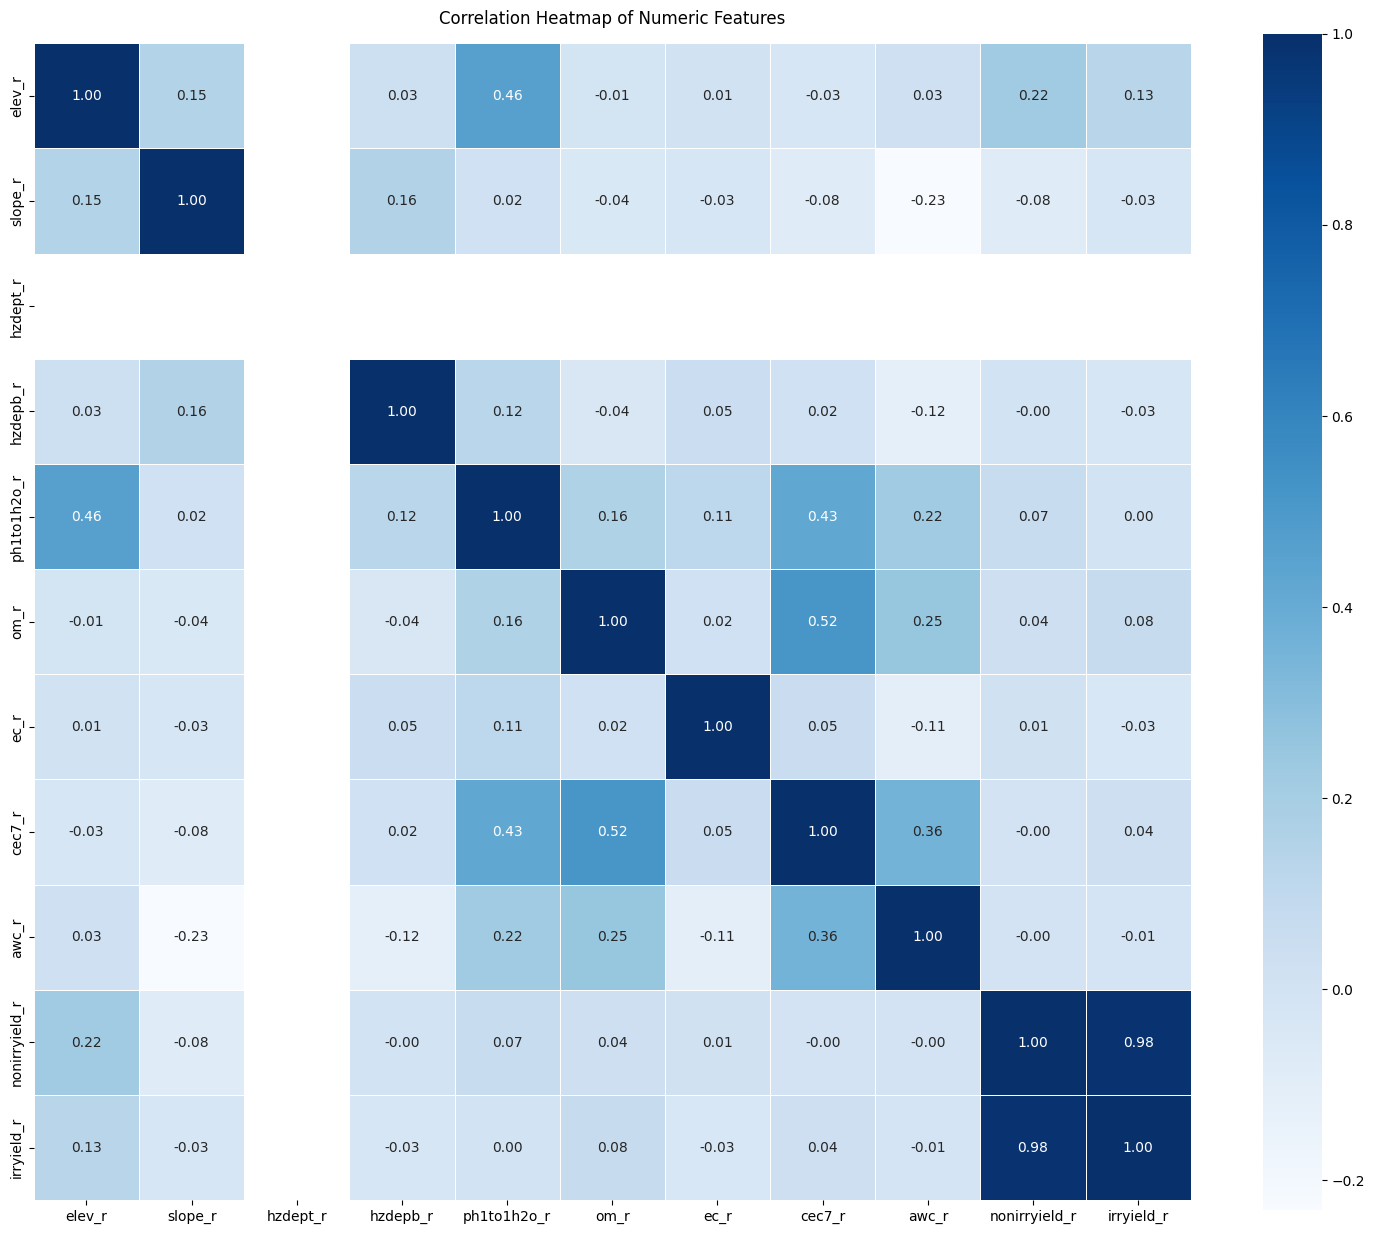

In [63]:
fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

In [41]:
df_weather.head()

,month,precip_total_mm,tmax_avg_c,tmin_avg_c
0,1,142.129801,13.523555,0.709614
1,2,52.344039,20.605166,6.838600
2,3,72.336391,22.507501,9.732189
3,4,117.734116,26.569030,13.842879
4,5,168.267623,30.941369,19.140074


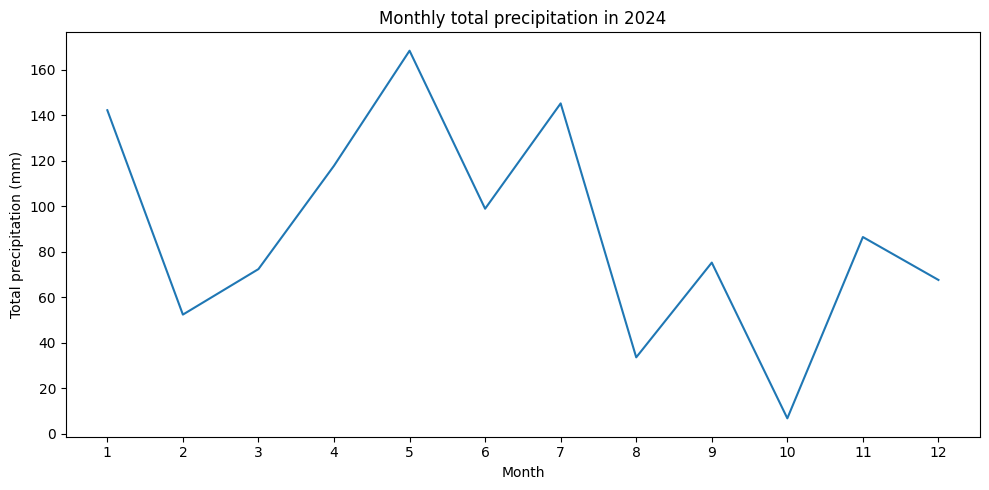

In [42]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=df_weather['month'], y=df_weather['precip_total_mm'])
plt.xticks(range(1, 13))
plt.title("Monthly total precipitation in 2024")
plt.xlabel("Month")
plt.ylabel("Total precipitation (mm)")
plt.tight_layout()
plt.show()